<a href="https://colab.research.google.com/github/LunaGar1/Pratica2-Vision-e-IA/blob/main/P2_reto1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto 1: Clasificación de flores parte 1

In [ ]:
from urllib.request import urlretrieve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

### Leer Dataset

In [ ]:
irisURL = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
urlretrieve(irisURL)
df_iris = pd.read_csv(irisURL, sep=',', names=["Largo_Sepalo", "Ancho_Sepalo", "Largo_Petalo", "Ancho_Petalo", "Clase"])

In [ ]:
print(df_iris)
print(df_iris.head())
print(df_iris.tail())

     Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo           Clase
0             5.1           3.5           1.4           0.2     Iris-setosa
1             4.9           3.0           1.4           0.2     Iris-setosa
2             4.7           3.2           1.3           0.2     Iris-setosa
3             4.6           3.1           1.5           0.2     Iris-setosa
4             5.0           3.6           1.4           0.2     Iris-setosa
..            ...           ...           ...           ...             ...
145           6.7           3.0           5.2           2.3  Iris-virginica
146           6.3           2.5           5.0           1.9  Iris-virginica
147           6.5           3.0           5.2           2.0  Iris-virginica
148           6.2           3.4           5.4           2.3  Iris-virginica
149           5.9           3.0           5.1           1.8  Iris-virginica

[150 rows x 5 columns]
   Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo       

## <span style="color:yellow">Regresión Logística</span>

In [ ]:
X_log = df_iris.drop('Clase', axis=1).copy()
y_log = df_iris['Clase'].copy()


In [ ]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

### Entrenar modelo logístico

In [ ]:
model_logistic = LogisticRegression(max_iter=500)
model_logistic.fit(X_train_log, y_train_log)

LogisticRegression(max_iter=500)

In [ ]:
y_pred_logistic = model_logistic.predict(X_test_log)

# print(y_pred_logistic)

### Validaciones

In [ ]:
accuracy_log = accuracy_score(y_test_log, y_pred_logistic)

print(f"Precision Logistica: {accuracy_log}")

Precision Logistica: 1.0


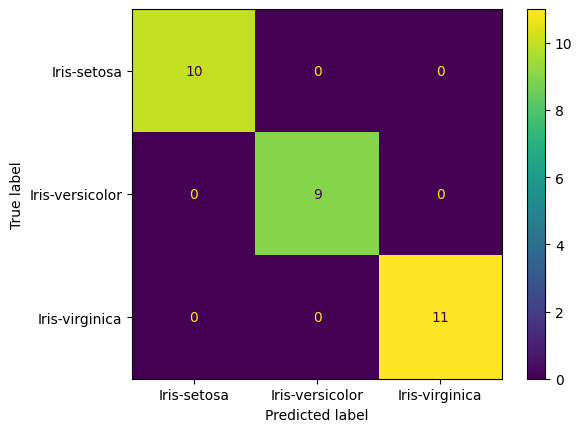

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_log, y_pred_logistic)

## <span style="color:yellow">Regresión Lineal</span>

### Separar X, y, entrenamiento y pruebas

In [ ]:
X_lin = df_iris.drop('Clase', axis=1).copy()
le = LabelEncoder()
y_lin = le.fit_transform(df_iris['Clase']).copy()

In [ ]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

### Entrenar modelo lineal

In [ ]:
model_lineal = LinearRegression()
model_lineal.fit(X_train_lin, y_train_lin)

LinearRegression()

In [ ]:
y_pred_lineal = model_lineal.predict(X_test_lin)

# print(y_pred_lineal)

In [ ]:
y_rounded = np.round(y_pred_lineal)
y_rounded = np.clip(y_rounded, 0, 2)

print(y_rounded)

[ 1. -0.  2.  1.  1.  0.  1.  2.  1.  1.  2. -0. -0. -0. -0.  1.  2.  1.
  1.  2.  0.  2.  0.  2.  2.  2.  2.  2.  0.  0.]


### Validaciones

In [ ]:
accuracy_lin = accuracy_score(y_test_lin, y_rounded)
mae = mean_absolute_error(y_test_lin, y_rounded)
mse = mean_squared_error(y_test_lin, y_rounded)

print(f"Precision Lineal: {accuracy_lin}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

Precision Lineal: 1.0
MAE: 0.0
MSE: 0.0


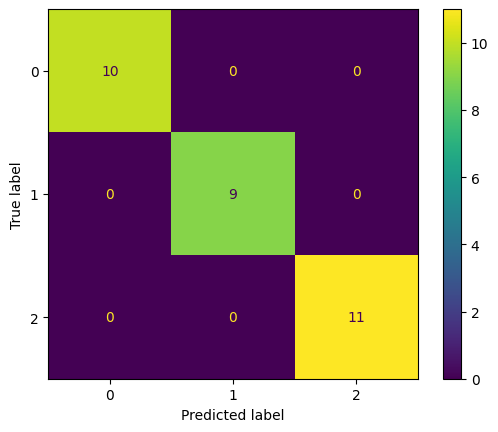

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_lin, y_rounded)

## <span style="color:yellow">Arboles de Decisión</span>

In [ ]:
X_tree = df_iris.drop('Clase', axis=1).copy()
y_tree = df_iris['Clase'].copy()

In [ ]:
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

### Entrenar modelo arbol de decisión

In [ ]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_tree, y_train_tree)

print("Profundidad del árbol sin Poda:", tree.get_depth())
print("Número de hojas sin Poda:", tree.get_n_leaves())

Profundidad del árbol sin Poda: 6
Número de hojas sin Poda: 10


In [ ]:
path = tree.cost_complexity_pruning_path(X_train_tree, y_train_tree)
ccp_alphas = path.ccp_alphas

print("Valores de ccp_alpha:", ccp_alphas)

Valores de ccp_alpha: [0.         0.00809524 0.01111111 0.01111111 0.01621622 0.0241196
 0.24326537 0.33340278]


In [ ]:
trees = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42, ccp_alpha=alpha)
    clf.fit(X_train_tree, y_train_tree)
    trees.append(clf)

In [ ]:
train_scores = []
test_scores = []

for clf in trees:
    train_scores.append(clf.score(X_train_tree, y_train_tree))
    test_scores.append(clf.score(X_test_tree, y_test_tree))

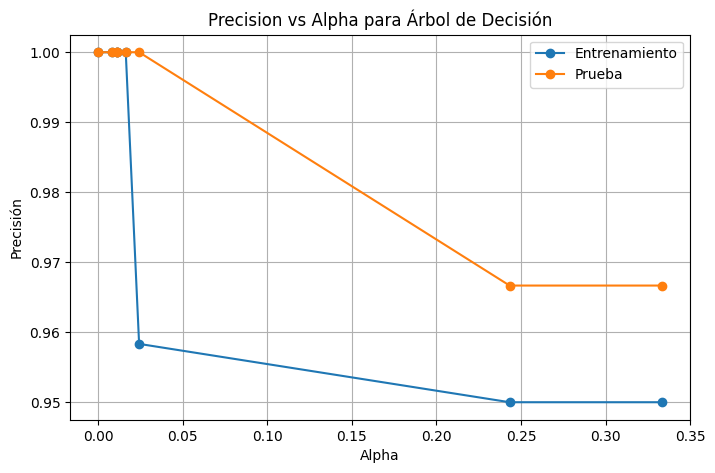

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_scores, label="Entrenamiento", marker='o')
plt.plot(ccp_alphas, test_scores, label="Prueba", marker='o')
plt.xlabel("Alpha")
plt.ylabel("Precisión")
plt.title("Precision vs Alpha para Árbol de Decisión")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_index = np.argmax(test_scores)
best_alpha = ccp_alphas[best_index]
print("Mejor alpha:", best_alpha)
print("Precision con mejor alpha:", test_scores[best_index])

Mejor alpha: 0.0
Precision con mejor alpha: 1.0


In [ ]:
final_tree = DecisionTreeClassifier(criterion='entropy', random_state=42, ccp_alpha=best_alpha)
final_tree.fit(X_train_tree, y_train_tree)
print("Profundidad del árbol final:", final_tree.get_depth())
print("Número de hojas del árbol final:", final_tree.get_n_leaves())

Profundidad del árbol final: 6
Número de hojas del árbol final: 10


In [ ]:
y_pred_tree = tree.predict(X_test_tree)

print(y_pred_tree)

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


### Validaciones

In [ ]:
accuracy_tree = accuracy_score(y_test_tree, y_pred_tree)

print(f"Precision Arbol de Decision: {accuracy_tree}")

Precision Arbol de Decision: 1.0


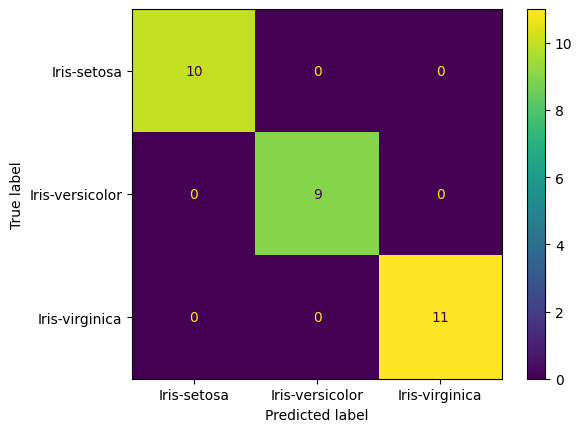

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_tree, y_pred_tree)

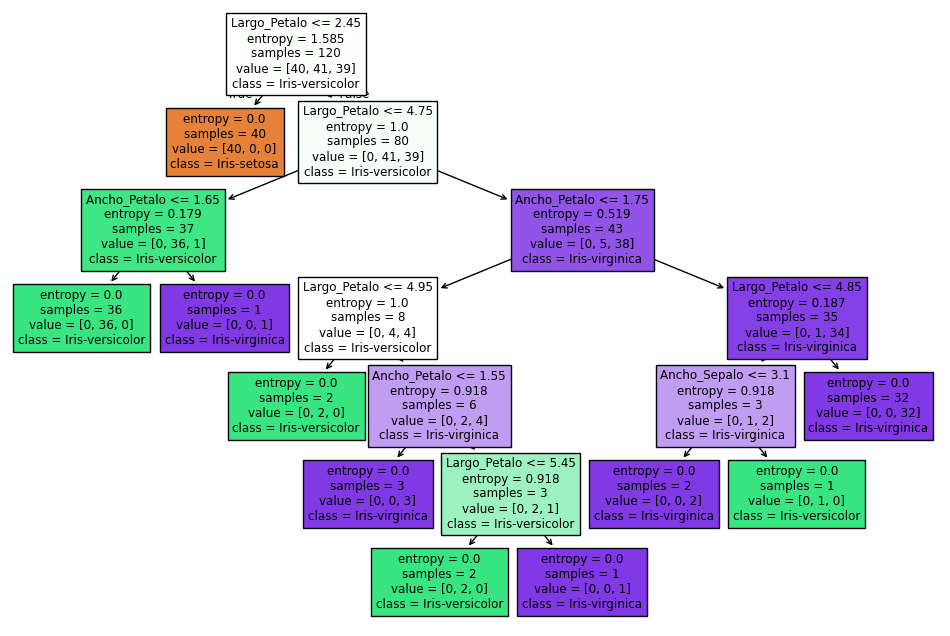

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(final_tree, filled=True, feature_names=X_tree.columns, class_names=tree.classes_.astype(str))
plt.show()

## <span style="color:yellow">Bosques Aleatorios</span>

In [ ]:
X_forest = df_iris.drop('Clase', axis=1).copy()
y_forest = df_iris['Clase'].copy()

In [ ]:
X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(X_forest, y_forest, test_size=0.2, random_state=42)

### Entrenar modelo arbol de decisión

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, max_features=2)
rf.fit(X_train_forest, y_train_forest)

RandomForestClassifier(max_features=2, random_state=42)

In [ ]:
y_pred_forest = rf.predict(X_test_forest)

print(y_pred_forest)

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


### Validaciones

In [ ]:
accuracy_forest = accuracy_score(y_test_forest, y_pred_forest)

print(f"Precision Bosque Aleatorio: {accuracy_forest}")

Precision Bosque Aleatorio: 1.0


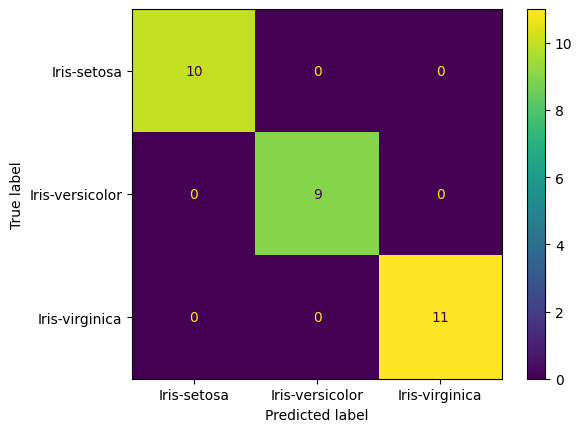

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_forest, y_pred_forest)

Text(0.5, 0, 'Importancia')

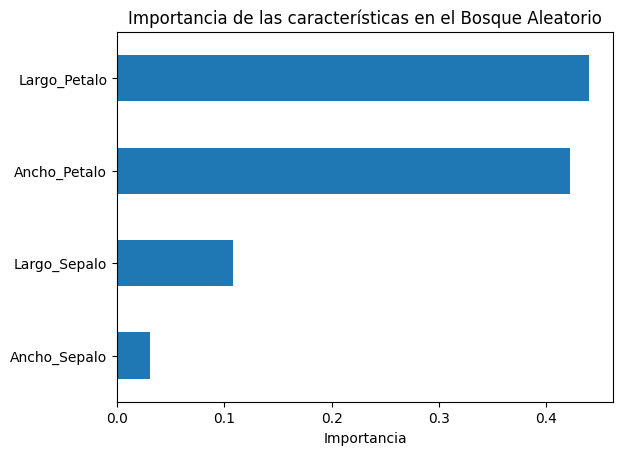

In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X_forest.columns)
importancias.sort_values().plot(kind='barh')
plt.title("Importancia de las características en el Bosque Aleatorio")
plt.xlabel("Importancia")

## <span style="color:red">Predecir</span>

In [ ]:
nueva_flor = np.array([[8, 3, 8, 0.2]])

prediccion_logistica = model_logistic.predict(nueva_flor)
prediccion_lineal = model_lineal.predict(nueva_flor)
prediccion_final_tree = final_tree.predict(nueva_flor)
prediccion_rf = rf.predict(nueva_flor)

print(f"Predicción Logística: {prediccion_logistica[0]}")
print(f"Predicción Lineal: {le.inverse_transform([int(round(prediccion_lineal[0]))])[0]}")
print(f"Predicción Árbol de Decisión: {prediccion_final_tree[0]}")
print(f"Predicción Bosque Aleatorio: {prediccion_rf[0]}")

Predicción Logística: Iris-virginica
Predicción Lineal: Iris-versicolor
Predicción Árbol de Decisión: Iris-virginica
Predicción Bosque Aleatorio: Iris-virginica


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## <span style="color:red">Conclusiones</span>

<ul>
    <li>
        La <strong>Regresión Logística</strong> es un modelo adecuado para problemas de clasificación, como se demostró con una precisión del 1.0. Su interpretabilidad es mayor que la de la regresión lineal para este tipo de tareas.
    </li>
    <li>
        La <strong>Regresión Lineal</strong> no es un buen modelo para clasificar en general, y mucho menos el dataset Iris que tiene como salida una clase. Para que funcione, se debe realizar una conversión previa de las clases a una interpretación numérica y, además, cuando el modelo se entrena no predice números enteros sino valores confusos que incluso pueden ser negativos. Para hacer la predicción de la clase de la flor, se debe redondear y esto es una mala práctica que puede resultar en predicciones erróneas. En este caso 'funcionó' y alcanzó una precisión del 1.0 solo porque el dataset Iris es pequeño.
    </li>
    <li>
        Cuando utilizamos el método <strong>Árbol de Decisión</strong> vimos que no genera fronteras lineales, sino que divide el espacio mediante reglas binarias. Es un método que tiende al sobreajuste. Esto lo hicimos principalmente con Poda, obteniendo unos alphas para penalizar complejidad y ver las diferentes precisiones. El gráfico de 'Precision vs Alpha para Árbol de Decisión'muestra cómo la precisión en entrenamiento y prueba varía.
    </li>
    <li>
        Para el método <strong>Bosques Aleatorios</strong> pudimos ver que es una versión mejorada respecto a un solo árbol, pues es menos sensible al sobreajuste y generaliza mejor, además que permite ver la importancia de las variables. El modelo alcanzó una precisión de 1.0. La importancia de las características, muestra que 'Largo_Petalo' y 'Ancho_Petalo' fueron las características más influyentes en la clasificación. Es un excelente método para clasificar, tiene bastantes parámetros a modificar y, además, hace las iteraciones suficientes para llegar a un buen modelo.
    </li>
    <li>
        Comparando entre diferentes modelos, la mayoría tienen bajo riesgo de sobreajuste, exceptuando el <strong>Árbol de Decisión</strong> si no se controla. La interpretabilidad que tiene la <strong>Regresión Lineal</strong> es baja para clasificación, mientras que la de la <strong>Regresión Logística</strong> y <strong>Árbol de Decisión</strong> es mayor. Concluimos que el rendimiento para el dataset Iris es aceptable para <strong>Regresión Lineal</strong> solo porque funciona por coincidencia, mientras que los demás son excelentes modelos. En todos los modelos aplicados, obtuvimos una precisión de 1.0, lo que significa que la capacidad de los modelos para predecir fue perfecta. Esto sucede principalmente porque el dataset usado es pequeño para el aprendizaje automático por lo que no se necesita el modelo más potente para hacer una buena predicción sobre el mismo.
    </li>
</ul>